<a href="https://colab.research.google.com/github/rayeenx/ImageCaptioningproject-CNN-LSTM/blob/main/imgCaptioningprojectRayan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matplotlib pillow

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving captions.txt to captions.txt


In [1]:
captions = {}
with open('captions.txt', 'r') as f:
  for line in f:
    parts=line.strip().split(',')
    img=parts[0]
    cap=",".join(parts[1:])

    if img not in captions:
      captions[img]=[]
    captions[img].append(cap)

FileNotFoundError: [Errno 2] No such file or directory: 'captions.txt'

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 84713990_d3f3cef78b.jpg to 84713990_d3f3cef78b.jpg


['A group of people on a blue raft going down a river .', 'A group of people paddle their blue inflatable raft down the rapids .', 'a group of people white water rafting in a blue raft .', 'Several people are rafting down a choppy river in rocky terrain .', 'Some people are riding a raft down a white water river .']


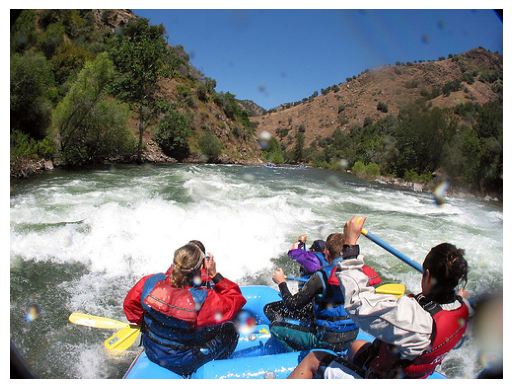

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
img_name="84713990_d3f3cef78b.jpg"
img = Image.open(img_name)
plt.imshow(img)
plt.axis('off')
print(captions.get(img_name, "NO cap"))

# Section : Preprocessing

**Cleaning:**

so i cleaned all captions to make the text consistent for the model
first i converted all words to lowercase to avoid treating words like Dogs and dogs as different.
Then, we removed punctuations so that the model works with simpler and cleaner sentences

**tokens:**

i added special tokens starteq and endeq to each caption
these captions help the LSTM model understand when to start and stop generating a sentence

**vocabulary:**

 i built a vocabulary conatining all unique words for the caption
each word is assigned a unique index (number) because the model cannot process text directly and requires numerical input
this vocabulary also defines the size of the embedding layer in the model

**sequence :**

Finally i converted each caption into a sequence of numbers using the vocabulary mapping
this is necessary because LSTM models work with sequences of numbers aand language is naturally sequential

In [ ]:
import string
def clean_caption(caption):
  caption=caption.lower()
  caption=caption.translate(str.maketrans('','',string.punctuation))
  return caption

for key in captions:
  captions[key]=[clean_caption(c) for c in captions[key]]
print(captions.get("84713990_d3f3cef78b.jpg"))
for key in captions:
    new_list = []
    for c in captions[key]:
        if not c.startswith("startseq"):
            c = "startseq " + c + " endseq"
        new_list.append(c)
    captions[key] = new_list
print(captions.get("84713990_d3f3cef78b.jpg"))


['a group of people on a blue raft going down a river ', 'a group of people paddle their blue inflatable raft down the rapids ', 'a group of people white water rafting in a blue raft ', 'several people are rafting down a choppy river in rocky terrain ', 'some people are riding a raft down a white water river ']
['startseq a group of people on a blue raft going down a river  endseq', 'startseq a group of people paddle their blue inflatable raft down the rapids  endseq', 'startseq a group of people white water rafting in a blue raft  endseq', 'startseq several people are rafting down a choppy river in rocky terrain  endseq', 'startseq some people are riding a raft down a white water river  endseq']


In [ ]:
all_captions = []
for cap in captions.values():
  all_captions.extend(cap)
all_captions=all_captions[1:]

vocab=set() #container of unique words assign indices to words model understand numbers
for cap in all_captions:
  for word in cap.split():
    vocab.add(word)
print("vocab size:", len(vocab)) #lstm need a fixed vocabulary size



vocab size: 8830


In [ ]:
word_to_index ={word: i+1 for i, word in enumerate(vocab)} #i+a cause 0 is preserved for le padding
index_to_word={i: word for word,i in word_to_index.items()} #decode predic

In [ ]:
def caption_to_sequence(caption):
  return [word_to_index[word] for word in caption.split()]
print(all_captions[2])
print(caption_to_sequence(all_captions[2]))

startseq a little girl climbing into a wooden playhouse  endseq
[2177, 5611, 358, 930, 7232, 5223, 5611, 6243, 179, 8710]


# **Section : Training**
i trained the model using a data generator to effciently handle a large dataset without loading everything into memory . The model learns to predict the next word in a caption based on image features and previously generated words. I used categorial crossentropy as the loss function (model predict one word from a vocabulary) and adam as the optimizer

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
import numpy as np
import os

In [ ]:
model=ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Print the last 5 layers to see their real names
for layer in model.layers[-5:]:
    print(layer.name)

conv5_block3_3_bn
conv5_block3_add
conv5_block3_out
avg_pool
predictions


In [ ]:
max_length=max_length= max(len(c.split())for c in all_captions)
print(max_length)
vocab_size= len(vocab)+1
steps = len(captions)
batch_size=64

38


In [ ]:
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add
from tensorflow.keras.models import Model

# --- 1. IMAGE BRANCH (Input 1) ---
# This expects the 2048 numbers we saved earlier
inputs1 = Input(shape=(2048,), name="image_input")
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# --- 2. TEXT BRANCH (Input 2) ---
# This expects the sequence of words (max_length = 38)
inputs2 = Input(shape=(max_length,), name="text_input")
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# --- 3. MERGE ---
decoder1 = Add()([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# --- 4. THE FIX ---
# We define the model with BOTH inputs in a list
caption_model = Model(inputs=[inputs1, inputs2], outputs=outputs)

caption_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(caption_model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,736 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 38, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 38)        │          0 │ text_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8831)      │  2,269,567 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,645,951 (21.54 MB)

 Trainable params: 5,645,951 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
img_path="84713990_d3f3cef78b.jpg"
img= image.load_img(img_path, target_size=(224, 224))
img= image.img_to_array(img)
img= np.expand_dims(img, axis=0)
img=preprocess_input(img)

In [ ]:
features = model.predict(img)
print(features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
(1, 1000)


In [ ]:
image_features={}
image_features[img_name]=features[0]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:

def find_images_folder(start_path="/content/drive/MyDrive"):
    print("🔍 Searching your Google Drive for the 'Images' folder...")
    for root, dirs, files in os.walk(start_path):
        if "Images" in dirs:
            full_path = os.path.join(root, "Images")
            # Make sure it's the one with lots of files
            if len(os.listdir(full_path)) > 10:
                return full_path
    return None

# Start the search
images_dir = find_images_folder()

if images_dir:
    print(f"✅ FOUND IT! Use this path:")
    print(f"images_dir = '{images_dir}'")

    # Test a sample file
    sample = os.listdir(images_dir)[0]
    print(f"Sample file found: {sample}")
else:
    print("❌ Still can't find it. Is the folder named something else (like 'Flickr8k')?")

In [ ]:

from tqdm.notebook import tqdm

# 1. Use the path the search script found
images_dir = '/content/drive/MyDrive/Images'

image_features = {}

# 2. Convert keys to a list so we can use the progress bar
image_names = list(captions.keys())

print(f"Starting extraction for {len(image_names)} images...")

for img_name in tqdm(image_names):
    try:
        # Build path
        img_path = os.path.join(images_dir, img_name)

        # Load and Preprocess
        img = image.load_img(img_path, target_size=(224, 224))
        img = image.img_to_array(img)
        img = np.expand_dims(img, axis=0)
        img = preprocess_input(img)

        # Extract Features (ResNet50)
        features = model.predict(img, verbose=0)

        # Store the 2048-dim vector
        image_features[img_name] = features[0]

    except Exception as e:
        # If a specific image fails, we just move on
        continue

print(f"\n✅ Done! Extracted features for {len(image_features)} images.")

In [ ]:
import pickle

# Save to your Drive so it's permanent
save_path = "/content/drive/MyDrive/image_features.pkl"

with open(save_path, "wb") as f:
    pickle.dump(image_features, f)

print(f"✅ Features saved to {save_path}")

In [ ]:
import pickle
from google.colab import drive

# 1. Remount your drive
drive.mount('/content/drive')

# 2. Load the features in seconds
with open("/content/drive/MyDrive/image_features.pkl", "rb") as f:
    image_features = pickle.load(f)

print(f"✅ Loaded {len(image_features)} image features instantly!")

Mounted at /content/drive
✅ Loaded 8091 image features instantly!


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences #for padding
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add #softmax to convert nb to float for probability
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:

def data_generator(captions, image_features, word_to_index, max_length, vocab_size, batch_size):
  while True:
    x1, x2, y = [],[],[] #x1 l image , x2 c que le model a deja lis, y le mot a deviner
    n=0
    for img_name, caps in captions.items():
      if img_name not in image_features:
        continue
      for cap in caps:
        seq=[word_to_index[word] for word in cap.split()]
        for i in range(1,len(seq)):
          in_seq=seq[:i]
          out_seq=seq[i]
          in_seq=pad_sequences([in_seq],maxlen=max_length)[0]
          in_seq= pad_sequences([in_seq],maxlen=max_length)[0]
          out_seq=to_categorical([out_seq], num_classes=len(vocab)+1)[0]
          x1.append(image_features[img_name])
          x2.append(in_seq)
          y.append(out_seq)
          n+=1
          if n == batch_size:
                        # On transforme x1 et x2 en un tuple d'arrays pour les entrées
                        # Et y en un array pour la cible
                        yield ((np.array(x1), np.array(x2)), np.array(y))
                        x1, x2, y = [], [], []
                        n = 0
             #yield donne 32 batch puis il reste en pause, il garde ou il etait puis reprend quand le model fini de s entrainer


In [ ]:
# Create the generator instance
limited_caption=dict(list(captions.items())[:5000])
test_gen = data_generator(limited_caption, image_features, word_to_index, max_length, vocab_size, batch_size)

# Get one single batch
inputs, outputs = next(test_gen)

print(f"Inputs shape: {inputs[0].shape}, {inputs[1].shape}")
print(f"Outputs shape: {outputs.shape}") # Should be (32, vocab_size)

Inputs shape: (64, 2048), (64, 38)
Outputs shape: (64, 8831)


# **Section** : **Optimization**
Due to computational limitation, i reduced the dataset size and training parameters (number of epochs and steps per epoch ). This allowed us to successfully train the model and demonstrate the full pipeline , while maintaining the core methodology of the original approach

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
generator= data_generator(captions, image_features, word_to_index, max_length, vocab_size, batch_size)
checkpoint = ModelCheckpoint('best_model.h5', monitor='loss', save_best_only=True, verbose=1)
# Réduit la vitesse learning rate
lr_scheduler = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=2, verbose=1)
# Arrête si ça ne progresse plus du tout (overfitting)
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
history = caption_model.fit(
    generator,
    steps_per_epoch=78,
    epochs=20,
    callbacks=[checkpoint, lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.3103 - loss: 3.6921
Epoch 1: loss improved from None to 3.76335, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 390ms/step - accuracy: 0.3079 - loss: 3.7633 - learning_rate: 0.0010
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.3206 - loss: 3.7297
Epoch 2: loss did not improve from 3.76335
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 389ms/step - accuracy: 0.3047 - loss: 3.8058 - learning_rate: 0.0010
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.3243 - loss: 3.6816
Epoch 3: loss improved from 3.76335 to 3.76045, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 381ms/step - accuracy: 0.3123 - loss: 3.7605 - learning_rate: 0.0010
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.3070 - loss: 3.7510
Epoch 4: loss did not improve from 3.76045
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 382ms/step - accuracy: 0.2947 - loss: 3.7875 - learning_rate: 0.0010
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.3209 - loss: 3.7241
Epoch 5: loss improved from 3.76045 to 3.72552, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 381ms/step - accuracy: 0.3127 - loss: 3.7255 - learning_rate: 0.0010
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.3089 - loss: 3.7316
Epoch 6: loss improved from 3.72552 to 3.70208, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - accuracy: 0.3151 - loss: 3.7021 - learning_rate: 0.0010
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.3357 - loss: 3.5996
Epoch 7: loss improved from 3.70208 to 3.56301, saving model to best_model.h5


...


Epoch 9: finished saving model to best_model.h5
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 381ms/step - accuracy: 0.3235 - loss: 3.5594 - learning_rate: 0.0010
Epoch 10/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.3387 - loss: 3.4841
Epoch 10: loss did not improve from 3.55941
78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 377ms/step - accuracy: 0.3185 - loss: 3.6440 - learning_rate: 0.0010
Epoch 11/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.3252 - loss: 3.6326
Epoch 11: loss improved from 3.55941 to 3.51029, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 380ms/step - accuracy: 0.3335 - loss: 3.5103 - learning_rate: 0.0010
Epoch 12/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.3217 - loss: 3.5121
Epoch 12: loss did not improve from 3.51029
78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 367ms/step - accuracy: 0.3253 - loss: 3.5416 - learning_rate: 0.0010
Epoch 13/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.3282 - loss: 3.4137
Epoch 13: loss improved from 3.51029 to 3.48406, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
78/78 ━━━━━━━━━━━━━━━━━━━━ 28s 362ms/step - accuracy: 0.3219 - loss: 3.4841 - learning_rate: 0.0010
Epoch 14/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.3062 - loss: 3.4523
Epoch 14: loss did not improve from 3.48406
78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 365ms/step - accuracy: 0.3181 - loss: 3.4953 - learning_rate: 0.0010
Epoch 15/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.3070 - loss: 3.5739
Epoch 15: loss did not improve from 3.48406

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 378ms/step - accuracy: 0.3171 - loss: 3.5290 - learning_rate: 0.0010
Epoch 16/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.3459 - loss: 3.3788
Epoch 16: loss did not improve from 3.48406
78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 378ms/step - accuracy: 0.3267 - loss: 3.5227 - learning_rate: 5.0000e-04
Epoch 17/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.3374 - l


Epoch 17: finished saving model to best_model.h5
78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 378ms/step - accuracy: 0.3393 - loss: 3.4172 - learning_rate: 5.0000e-04
Epoch 18/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.3310 - loss: 3.3434
Epoch 18: loss improved from 3.41724 to 3.27107, saving model to best_model.h5



Epoch 18: finished saving model to best_model.h5
78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 377ms/step - accuracy: 0.3446 - loss: 3.2711 - learning_rate: 5.0000e-04
Epoch 19/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.3680 - loss: 3.2726
Epoch 19: loss did not improve from 3.27107
78/78 ━━━━━━━━━━━━━━━━━━━━ 30s 380ms/step - accuracy: 0.3678 - loss: 3.3147 - learning_rate: 5.0000e-04
Epoch 20/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.3275 - loss: 3.4319
Epoch 20: loss did not improve from 3.27107

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 378ms/step - accuracy: 0.3231 - loss: 3.4761 - learning_rate: 5.0000e-04


In [ ]:
model.save('/content/drive/MyDrive/mon_modele_captioning.h5')
print("✅ Modèle sauvegardé avec succès sur Google Drive !")

✅ Modèle sauvegardé avec succès sur Google Drive !


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/mon_modele_captioning.h5')

In [ ]:
def generate_caption(image_features, model, word_to_index, index_to_word, max_length):
  in_text="startseq"
  for i in range(max_length):
    sequence=[word_to_index[w] for w in in_text.split() if w in word_to_index]
    sequence=pad_sequences([sequence],maxlen=max_length)


    yhat = model.predict([image_features.reshape(1,2048), sequence] ,verbose=0)
    yhat=np.argmax(yhat)
    word=index_to_word.get(yhat)
    if word is None:
      break
    in_text+=" "+word
    if word=="endseq":
      break
  return in_text

In [ ]:
img_name=list(image_features.keys())[0]
feature=image_features[img_name]
caption=generate_caption(feature, caption_model, word_to_index, index_to_word, max_length)
print("generated:", caption)

generated: startseq a boy is playing on a red ball endseq


In [ ]:
def clean_captionn(caption):
  words= caption.split()
  words= [w for w in words if w not in ["startseq", "endseq"]]
  return " ".join(words)
print("final:",clean_captionn(caption))

final: a boy is playing on a red ball


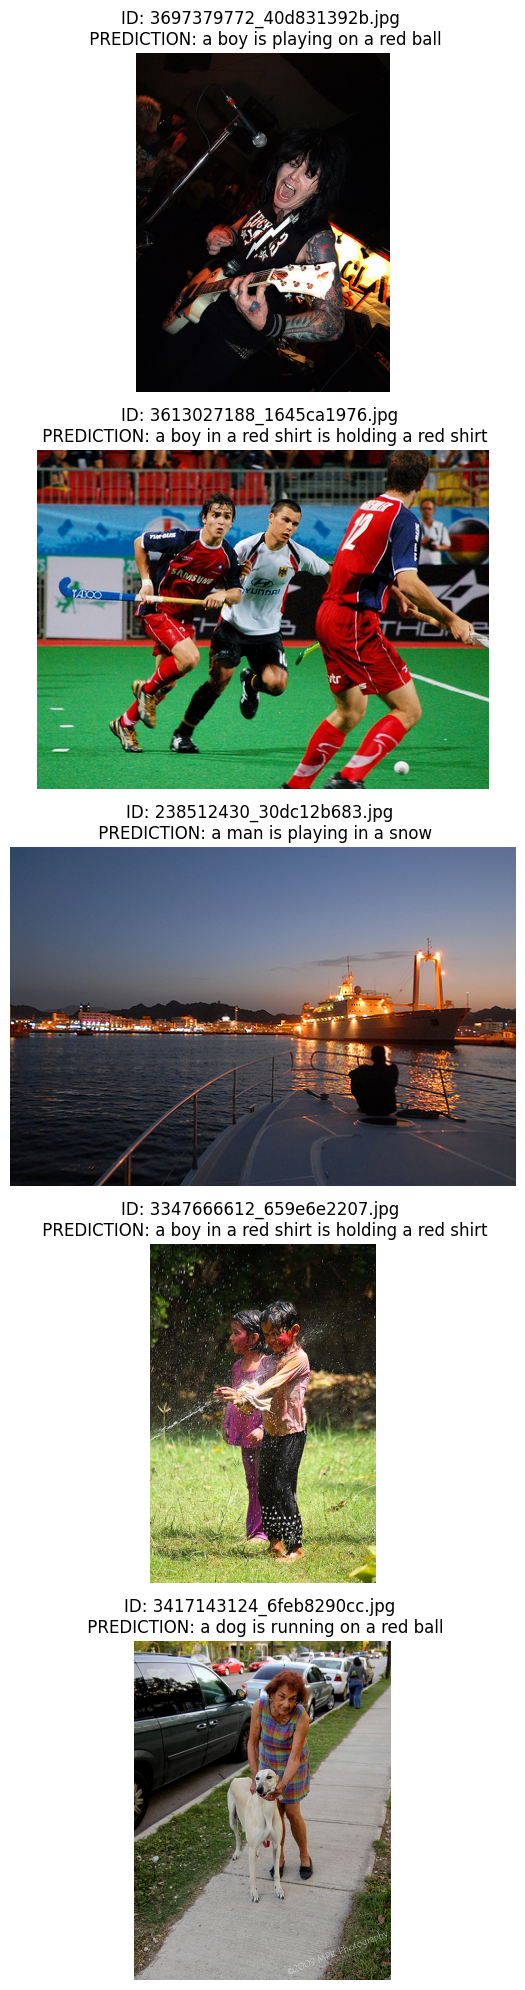

In [ ]:
import random
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np
# 1. Choisir 5 images au hasard dans ton dictionnaire de test
test_images = random.sample(list(image_features.keys()), 5)

plt.figure(figsize=(20, 20))

for i, img_id in enumerate(test_images):
    # Génération
    feature_vec = image_features[img_id]
    raw_caption = generate_caption(feature_vec, caption_model, word_to_index, index_to_word, max_length)
    final_caption = clean_captionn(raw_caption) # Ta fonction de nettoyage

    # Affichage
    img_path = os.path.join("/content/drive/MyDrive/Images/", img_id)
    ax = plt.subplot(5, 1, i + 1)
    if os.path.exists(img_path):
        ax.imshow(Image.open(img_path))
        ax.set_title(f"ID: {img_id} \n PREDICTION: {final_caption}", fontsize=12)
        ax.axis('off')

plt.tight_layout()
plt.show()